In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [188]:
df=pd.read_csv("C:\\Users\\DELL\\Desktop\\Talentlock\\talentlock_cleaned.csv")

In [189]:
# Dropping unnecessary columns before encoding
df.drop(['Marital_Status', 'Hourly_Rate', 'Average_Hours_Worked_Per_Week', 'Distance_From_Home'], axis=1, inplace=True)

In [190]:
df.shape

(10000, 21)

In [191]:
from sklearn.preprocessing import LabelEncoder

- **LabelEncoder:** Used to convert categorical data into numerical format

In [192]:
le = LabelEncoder()

df['Attrition'] = le.fit_transform(df['Attrition'])
df['Gender'] = le.fit_transform(df['Gender'])
df['Department'] = le.fit_transform(df['Department'])
df['Job_Role'] = le.fit_transform(df['Job_Role'])
df['Overtime'] = le.fit_transform(df['Overtime'])

- **LabelEncoder():** Converts categorical columns (Attrition, Gender, Department, Job_Role, Overtime) into numerical values, where output shows encoded integer values replacing text categories for machine learning compatibility

In [193]:
df['Experience_Ratio'] = df['Years_at_Company'] / df['Age']
# Income per year experience
df['Income_Per_Year'] = df['Monthly_Income'] / (df['Years_at_Company'] + 1)

# Stability score
df['Stability'] = df['Years_at_Company'] / (df['Number_of_Companies_Worked'] + 1)

- **Feature Engineering (new columns creation):** Creates Experience_Ratio, Income_Per_Year and Stability features, where output adds new calculated columns to dataset for better analysis and improved model performance

In [194]:
df.head()

,Age,Gender,Department,Job_Role,Job_Level,Monthly_Income,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,...,Project_Count,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Number_of_Companies_Worked,Attrition,Experience_Ratio,Income_Per_Year,Stability
0,58,1,0,3,5,7332.0,24,12,3,1.0,...,9,16,4,1,1,3,0,0.413793,293.280000,6.0
1,48,0,1,1,4,6069.0,18,7,5,1.0,...,9,10,4,1,1,1,0,0.375000,319.421053,9.0
2,34,0,3,3,4,11387.0,6,4,3,4.0,...,3,1,1,4,3,1,1,0.176471,1626.714286,3.0
3,27,0,1,3,4,18707.0,12,9,1,1.0,...,9,2,3,4,1,2,0,0.444444,1439.000000,4.0
4,40,1,1,0,1,16398.0,3,9,1,2.0,...,1,11,1,1,1,4,0,0.075000,4099.500000,0.6


- **head():**  Displays first 5 rows of updated dataset including newly created features, where output shows modified dataframe with additional columns for verification

In [195]:
df['Attrition'].value_counts()

Attrition
0    8003
1    1997
Name: count, dtype: int64

In [196]:
# Split
X = df.drop('Attrition', axis=1)
y = df['Attrition']

- **drop() + target split**: Separates features (X) and target (y = Attrition), where output prepares independent and dependent variables for model training

In [197]:
from imblearn.over_sampling import SMOTE

- **SMOTE (Synthetic Minority Oversampling Technique)** is imported to handle imbalanced data.
It helps in increasing the number of samples in the minority class (Attrition = Yes).
This improves model performance by avoiding bias toward the majority class.

In [198]:
smote = SMOTE(random_state=42)

X_sm, y_sm = smote.fit_resample(X, y)

- SMOTE (Synthetic Minority Oversampling Technique) is imported to handle imbalanced data.
It helps in increasing the number of samples in the minority class (Attrition = Yes).
This improves model performance by avoiding bias toward the majority class.

In [199]:
print(y_sm.value_counts())

Attrition
0    8003
1    8003
Name: count, dtype: int64


- This step checks the distribution of the target variable after applying SMOTE.
It confirms that both classes now have equal number of samples.
This ensures the dataset is balanced and ready for model training.

In [200]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

- **train_test_split:** Used to split dataset into training and testing data
- **accuracy_score:** Used to evaluate model performance (prediction accuracy)

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2)

print(y_train)

9962     0
8858     0
2890     1
1555     1
15471    1
        ..
14875    1
6576     1
1147     1
9143     0
770      1
Name: Attrition, Length: 12804, dtype: int32


- **train_test_split():** Splits data into training and testing sets (80% train, 20% test), where output creates X_train, X_test, y_train, y_test for model evaluation
- **head():** Displays first few values of y_train, where output shows sample target values used for training

In [202]:
from sklearn.preprocessing import StandardScaler

- **StandardScaler:** Used for standardization (mean = 0, variance = 1)

In [203]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

- **StandardScaler():** Applies standard scaling (mean=0, std=1), where output transforms X_train and X_test into standardized values for better model performance

In [204]:
from sklearn.preprocessing import MinMaxScaler

- **MinMaxScaler:** Used for normalization (scaling values between 0 and 1)

In [205]:
mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)

- **MinMaxScaler():** Applies normalization to scale features between 0 and 1, where output transforms X_train and X_test into scaled values preserving relative distribution for model improvement

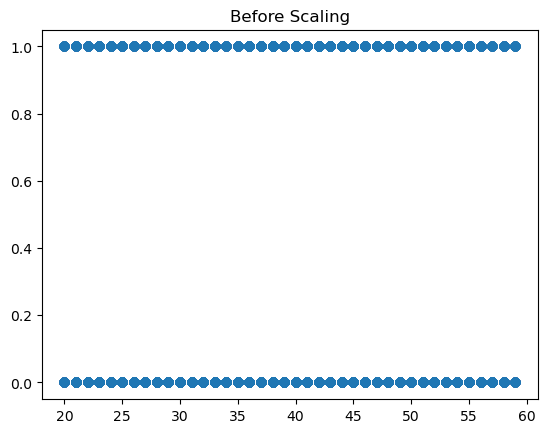

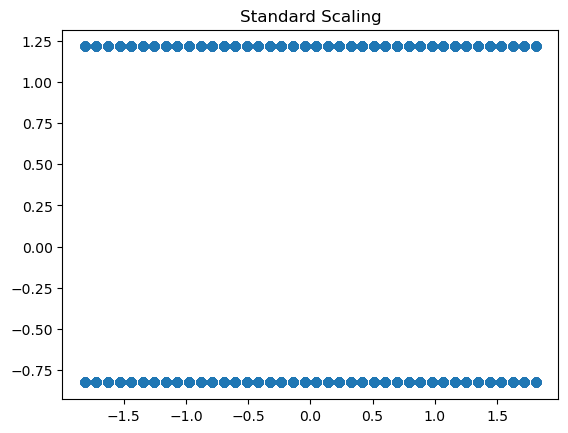

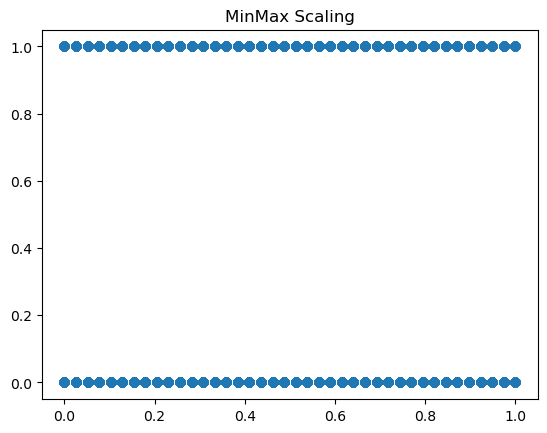

In [206]:
plt.scatter(X_train.iloc[:,0], X_train.iloc[:,1])
plt.title("Before Scaling")

plt.figure()
plt.scatter(X_train_std[:,0], X_train_std[:,1])
plt.title("Standard Scaling")

plt.figure()
plt.scatter(X_train_mm[:,0], X_train_mm[:,1])
plt.title("MinMax Scaling")

plt.show()

- **scatter() + scaling comparison:** Creates scatter plots before scaling, after Standard Scaling, and after MinMax Scaling, where output shows visual comparison of data distribution changes to understand impact of scaling techniques

In [207]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

- **LogisticRegression:** Used for classification problems (binary outcomes like Attrition Yes/No)
- **DecisionTreeClassifier:** Used to build tree-based model for decision making
- **RandomForestClassifier:** Used for ensemble learning (multiple trees for better accuracy)
- **SVC (Support Vector Classifier):** Used for classification using hyperplanes (SVM algorithm)
- **KNeighborsClassifier:** Used for classification based on nearest data points (KNN algorithm)#

In [208]:
lr = LogisticRegression(max_iter=1000)


- **LogisticRegression():** Initializes Logistic Regression model, where output prepares classification algorithm for training

In [209]:
lr.fit(X_train_std, y_train)

LogisticRegression(max_iter=1000)

- **fit():**  Trains Logistic Regression using standardized training data, where output builds learned model from input features

In [210]:
pred_lr = lr.predict(X_test_std)

- **predict():** Predicts Attrition values on test data, where output generates predicted labels

In [211]:
acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic:", acc_lr)

Logistic: 0.6951905059337914


- **accuracy_score():** Calculates accuracy of Logistic model, where output shows performance score 
- **print():** Displays Logistic Regression accuracy, where output shows model performance result

In [212]:
dt = DecisionTreeClassifier(max_depth=5)


- **DecisionTreeClassifier():** Initializes Decision Tree model with max_depth=5, where output prepares tree-based model

In [213]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

- **fit():** Trains Decision Tree on training data, where output builds decision rules from dataset

In [214]:
pred_dt = dt.predict(X_test)


- **predict():** Predicts values using Decision Tree, where output generates test predictions

In [215]:
acc_dt = accuracy_score(y_test, pred_dt)

print("Decision Tree:", acc_dt)

Decision Tree: 0.693628981886321


- **accuracy_score():** Calculates Decision Tree accuracy, where output shows model performance score
- **print():** Displays Decision Tree accuracy result

In [216]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10)


- **RandomForestClassifier():** Initializes Random Forest with 200 trees and depth 10, where output prepares ensemble model

In [217]:
rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200)

In [218]:
import pickle

# Save model
pickle.dump(rf, open("model.pkl", "wb"))

# Save columns (VERY IMPORTANT)
pickle.dump(X_train.columns.tolist(), open("columns.pkl", "wb"))

- **fit():** Trains Random Forest model, where output builds multiple decision trees


In [219]:
pred_rf = rf.predict(X_test)


- **predict():** Predicts using Random Forest, where output gives test predictions


In [220]:
acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest:", acc_rf)

Random Forest: 0.8135540287320425


- **accuracy_score():** Calculates Random Forest accuracy, where output shows model performance
- **print():** Displays Random Forest accuracy

In [221]:
svm = SVC()

- **SVC():** Initializes Support Vector Machine model, where output prepares SVM classifier


In [222]:
svm.fit(X_train_std, y_train)


SVC()

- **fit():** Trains SVM using standardized data, where output builds decision boundary


In [223]:
pred_svm = svm.predict(X_test_std)

- **predict():** Predicts using SVM, where output gives classification results


In [224]:
acc_svm = accuracy_score(y_test, pred_svm)

print("SVM:", acc_svm)

SVM: 0.7966895690193629


- **accuracy_score():** Calculates SVM accuracy, where output shows model performance
- **print():**  Displays SVM accuracy

In [225]:
knn = KNeighborsClassifier(n_neighbors=5)

- **KNeighborsClassifier():** Initializes KNN model with k=5 neighbors, where output prepares distance-based classifier


In [226]:
knn.fit(X_train_std, y_train)

KNeighborsClassifier()

- **fit():** Trains KNN model, where output stores training data for distance comparison

In [227]:
pred_knn = knn.predict(X_test_std)

- **predict():** Generates KNN predictions on test data, where output gives predicted Attrition values for evaluation

In [228]:
acc_knn = accuracy_score(y_test, pred_knn)

print("KNN:", acc_knn)

KNN: 0.7079950031230481


- **accuracy_score() + print():** Calculates and displays KNN model accuracy, where output shows performance score 

In [229]:
models = ["LR", "DT", "RF", "SVM", "KNN"]
accuracy = [acc_lr, acc_dt, acc_rf, acc_svm, acc_knn]

List creation: Stores model names and their accuracies in lists, where output prepares data for comparison visualization

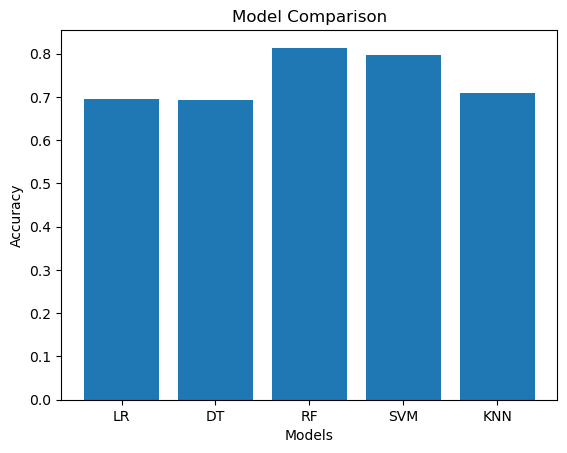

In [230]:
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

plt.bar(): Creates bar chart comparing accuracy of all models and identifies best model, where output shows visual comparison graph 

In [231]:
print("Best Model:", models[accuracy.index(max(accuracy))])

Best Model: RF


print(): prints model with highest accuracy